# From Pilot to Payoff - 03: Q2 - Country-Level Digital Readiness

Part of the IS630 group project. The original single notebook was split into 7 self-contained modules for readability. Run the setup block below first, then the Q2 analysis.

| # | Notebook | Content |
|---|---|---|
| 01 | Setup & Data Prep | Problem/objectives (S2), data sources & preparation (S3) |
| 02 | Q1 Global EDA | Section 4.1 |
| 03 | Q2 Country Readiness | Section 4.2 |
| 04 | Q3 Firm-Level Drivers | Section 4.3 |
| 05 | Q4 Business Payoff | Section 4.4 |
| 06 | Q5 Workforce & Bayesian | Section 4.5 |
| 07 | Conclusion & Summary | Section 5 |


## Setup and data preparation

*This block re-runs the shared imports, data loading, feature engineering, and standardisation so the notebook is self-contained. It is identical across the split modules; see `01_setup_and_data_prep.ipynb` for the fully documented version with data-quality checks and the data dictionary.*

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats

import statsmodels.api as sm
from statsmodels.formula.api import ols, logit
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupShuffleSplit

import matplotlib.pyplot as plt
import seaborn as sns

# Folder for saving generated figures.
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)


In [2]:
company = pd.read_csv('ai_company_adoption.csv')
country_index = pd.read_csv('country_ai_index.csv')
industry_summary = pd.read_csv('ai_industry_summary.csv')

print('Dataset shapes')
print(f'company adoption: {company.shape[0]:,} rows x {company.shape[1]:,} columns')
print(f'country index:    {country_index.shape[0]:,} rows x {country_index.shape[1]:,} columns')
print(f'industry summary: {industry_summary.shape[0]:,} rows x {industry_summary.shape[1]:,} columns')

company.head(3)


Dataset shapes
company adoption: 150,000 rows x 43 columns
country index:    30 rows x 8 columns
industry summary: 9 rows x 8 columns


,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation


In [3]:
# Feature engineering and merge.
quarter_map = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4}
company = company.copy()
company['quarter_num'] = company['quarter'].map(quarter_map)
company['time_index'] = company['survey_year'] * 4 + company['quarter_num']
company['advanced_adoption'] = company['ai_adoption_stage'].isin(['partial', 'full']).astype(int)
company['net_jobs_created'] = company['jobs_created'] - company['jobs_displaced']
company['net_jobs_per_100_employees'] = company['net_jobs_created'] / company['num_employees'] * 100
company['reskilling_rate_per_100_employees'] = company['reskilled_employees'] / company['num_employees'] * 100

# Log transforms for highly skewed scale variables. log1p handles zero values safely.
company['log_num_employees'] = np.log1p(company['num_employees'])
company['log_revenue'] = np.log1p(company['annual_revenue_usd_millions'])
company['log_ai_investment_per_employee'] = np.log1p(company['ai_investment_per_employee'])

country_model = country_index.drop(columns=['region'])
country_model['log_gdp_per_capita'] = np.log1p(country_model['gdp_per_capita'])
country_model['log_ai_patent_filings_2024'] = np.log1p(country_model['ai_patent_filings_2024'])

df = company.merge(country_model, on='country', how='left')

# Latest observation per company for robustness checks.
latest_obs = (df.sort_values(['company_id', 'survey_year', 'quarter_num'])
                .groupby('company_id', as_index=False)
                .tail(1)
                .reset_index(drop=True))

# Digital maturity tertiles for interaction models.
df['digital_maturity_tertile'] = pd.qcut(
    df['digital_maturity_index'], q=3, labels=['Low', 'Medium', 'High']
)
latest_obs['digital_maturity_tertile'] = pd.qcut(
    latest_obs['digital_maturity_index'], q=3, labels=['Low', 'Medium', 'High']
)

merge_check = df[['country', 'digital_maturity_index']].isna().mean().rename('missing_rate')
print(f'Merged modelling data: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
print(f'Latest-company robustness data: {latest_obs.shape[0]:,} rows')
print('\nCountry-index missing check:')
print(merge_check)


Merged modelling data: 150,000 rows x 61 columns
Latest-company robustness data: 10,000 rows

Country-index missing check:
country                   0.0
digital_maturity_index    0.0
Name: missing_rate, dtype: float64


In [4]:
# Standardise numeric predictors used in regression models.
standardise_cols = [
    'log_num_employees', 'company_age',
    'ai_training_hours', 'num_ai_tools_used', 'ai_projects_active', 'years_using_ai',
    'ai_budget_percentage', 'log_ai_investment_per_employee',
    'regulatory_compliance_score', 'ai_risk_management_score',
    'digital_maturity_index'
]

for col in standardise_cols:
    mean = df[col].mean()
    std = df[col].std(ddof=0)
    df[f'z_{col}'] = (df[col] - mean) / std
    latest_obs[f'z_{col}'] = (latest_obs[col] - mean) / std

print('Created z-score variables for regression comparability.')


Created z-score variables for regression comparability.


In [5]:
stage_order = ['none', 'pilot', 'partial', 'full']

### 4.2 Q2 - Country-Level Digital Readiness

This section corrects the proposal-feedback gap by using the actual `country_ai_index.csv` variables instead of only country-level averages from the main firm dataset. Because there are only 30 countries, the country-level results are exploratory.

We use Session 7 correlation/regression and Session 8 PCA ideas:

1. Correlate country readiness indicators with country-level advanced adoption.
2. Check VIF among readiness indicators.
3. Use PCA to form a single readiness index when indicators are strongly correlated.
4. Run a simple OLS model using the PCA readiness index.


In [6]:
country_level = (df.groupby('country')
                   .agg(
                       adv_adoption_rate=('advanced_adoption', 'mean'),
                       n=('advanced_adoption', 'size'),
                       region=('region', 'first'),
                       gdp_per_capita=('gdp_per_capita', 'first'),
                       log_gdp_per_capita=('log_gdp_per_capita', 'first'),
                       internet_penetration=('internet_penetration', 'first'),
                       digital_maturity_index=('digital_maturity_index', 'first'),
                       country_ai_policy=('country_ai_policy', 'first'),
                       ai_patent_filings_2024=('ai_patent_filings_2024', 'first'),
                       log_ai_patent_filings_2024=('log_ai_patent_filings_2024', 'first'),
                       ai_researchers_per_million=('ai_researchers_per_million', 'first'))
                   .reset_index())

readiness_features = [
    'log_gdp_per_capita',
    'internet_penetration',
    'digital_maturity_index',
    'log_ai_patent_filings_2024',
    'ai_researchers_per_million'
]

# Pearson correlation: each country readiness indicator vs country-level advanced adoption.
# H0: no linear association (rho = 0).  H1: rho != 0.  Reject H0 at alpha = 0.05.
corr_rows = []
for col in readiness_features:
    r, p = stats.pearsonr(country_level[col], country_level['adv_adoption_rate'])
    corr_rows.append({'readiness_indicator': col, 'pearson_r': r, 'p_value': p})

country_corr_table = pd.DataFrame(corr_rows).sort_values('pearson_r', ascending=False)
country_corr_table


,readiness_indicator,pearson_r,p_value
0,log_gdp_per_capita,0.643397,0.000125
4,ai_researchers_per_million,0.538635,0.002135
2,digital_maturity_index,0.537943,0.002169
1,internet_penetration,0.537669,0.002182
3,log_ai_patent_filings_2024,0.426704,0.018696


In [7]:
# VIF for country readiness variables.
def compute_vif(data, columns):
    X = data[columns].dropna().copy()
    X_std = pd.DataFrame(StandardScaler().fit_transform(X), columns=columns, index=X.index)
    X_const = sm.add_constant(X_std)
    return (pd.DataFrame({
        'variable': columns,
        'VIF': [variance_inflation_factor(X_const.values, i + 1) for i in range(len(columns))]
    }).sort_values('VIF', ascending=False))

country_vif = compute_vif(country_level, readiness_features)
country_vif


,variable,VIF
4,ai_researchers_per_million,17.911738
0,log_gdp_per_capita,16.985121
2,digital_maturity_index,14.819939
1,internet_penetration,9.564445
3,log_ai_patent_filings_2024,3.303517


PCA explained variance ratio
PC1    0.868
PC2    0.084
dtype: float64

PCA loadings
                   feature  PC1_loading  PC2_loading
        log_gdp_per_capita        0.459       -0.359
      internet_penetration        0.440       -0.508
    digital_maturity_index        0.464        0.149
log_ai_patent_filings_2024        0.407        0.768
ai_researchers_per_million        0.465        0.015

Country-level OLS: advanced adoption rate ~ readiness PC1
R2=0.335, Adj R2=0.311, p=0.0008


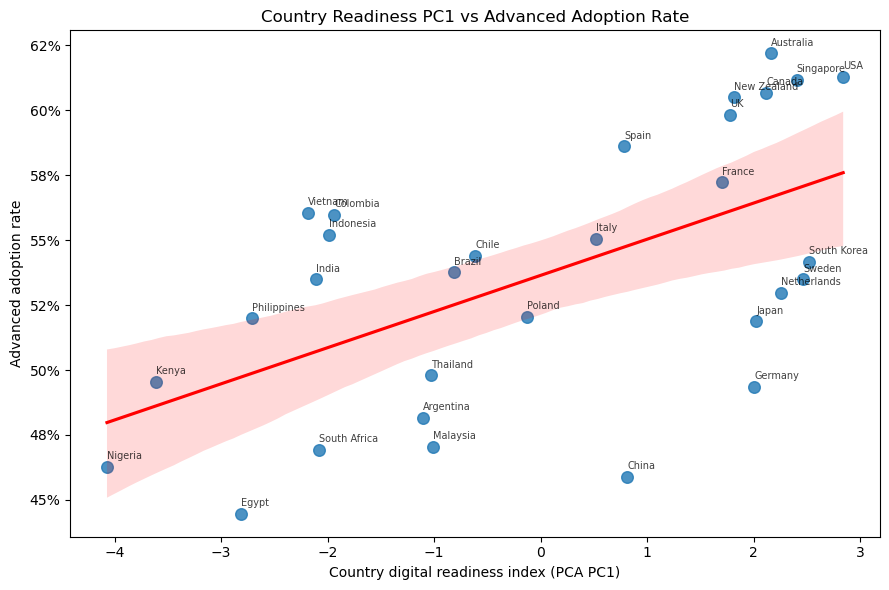

In [8]:
# PCA readiness index using standardised country readiness variables.
X_readiness = StandardScaler().fit_transform(country_level[readiness_features])
pca = PCA(n_components=2)
pca_scores = pca.fit_transform(X_readiness)

country_level['readiness_pc1'] = pca_scores[:, 0]
country_level['readiness_pc2'] = pca_scores[:, 1]

# Flip PC1 if needed so higher PC1 corresponds to higher digital maturity.
if country_level[['readiness_pc1', 'digital_maturity_index']].corr().iloc[0, 1] < 0:
    country_level['readiness_pc1'] *= -1
    pca.components_[0, :] *= -1

pca_loadings = pd.DataFrame({
    'feature': readiness_features,
    'PC1_loading': pca.components_[0],
    'PC2_loading': pca.components_[1]
})

print('PCA explained variance ratio')
print(pd.Series(pca.explained_variance_ratio_, index=['PC1', 'PC2']).round(3))
print('\nPCA loadings')
print(pca_loadings.round(3).to_string(index=False))

model_country_pc1 = ols('adv_adoption_rate ~ readiness_pc1', data=country_level).fit()
print('\nCountry-level OLS: advanced adoption rate ~ readiness PC1')
print(f'R2={model_country_pc1.rsquared:.3f}, Adj R2={model_country_pc1.rsquared_adj:.3f}, p={model_country_pc1.pvalues["readiness_pc1"]:.4f}')

fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(data=country_level, x='readiness_pc1', y='adv_adoption_rate', ax=ax,
            scatter_kws={'s': 70, 'alpha': 0.8}, line_kws={'color': 'red'})
for _, row in country_level.iterrows():
    ax.text(row['readiness_pc1'], row['adv_adoption_rate'] + 0.003, row['country'], fontsize=7, alpha=0.75)
ax.set_title('Country Readiness PC1 vs Advanced Adoption Rate')
ax.set_xlabel('Country digital readiness index (PCA PC1)')
ax.set_ylabel('Advanced adoption rate')
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_04_country_readiness_pca.png', bbox_inches='tight')
plt.show()


**Q2 interpretation.** Country readiness indicators are highly correlated with each other, so interpreting all of them in the same regression would be unstable. A PCA readiness index is a more defensible summary for this project. Because the analysis has only 30 country-level rows, the result should be treated as an exploratory association, not a causal estimate.
